# Esame Finale — Machine Learning Supervisionato

---

## Brief Aziendale

Sei un Data Scientist del team di **BIP AI LAB**. La nostra azienda collabora costantemente con diversi clienti operanti in svariati settori, aiutandoli a estrarre valore dai loro dati storici per supportare le decisioni strategiche del management.

A seconda del cliente a cui verrai assegnato, avrai a disposizione uno specifico dataset su cui sviluppare la tua soluzione predittiva. Tieni a mente che ogni dataset pone sfide differenti e richiede considerazioni e approcci mirati, soprattutto nelle fasi di analisi e preparazione dei dati.

## Istruzioni per lo Svolgimento

Il tuo compito principale sarà quello di scegliere il modello di machine learning supervisionato più appropriato per il tuo caso di studio, selezionandolo tra quelli affrontati durante il corso: la **Linear Regression** o la **Logistic Regression**.

Dovrai gestire l'intera pipeline per estrarre valore dai dati che ti sono stati assegnati, addestrare il modello secondo le tecniche studiate e valutarne l'output nel contesto specifico del problema. Poni particolare enfasi sulla comprensione del contesto dei dati: sarà fondamentale per compiere delle scelte analitiche mirate, che dovrai poi giustificare durante la presentazione finale.

Buon lavoro.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


plt.rcParams["figure.figsize"] = (7, 4.5)
RANDOM_STATE = 42

## 1. Caricamento dati

In [3]:
df = pd.read_csv("boston_housing.csv")
print("Numero di immobili:", len(df))
df.head()

Numero di immobili: 506


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.00,486.00,486.00,486.00,506.00,506.00,486.00,506.00,506.00,506.00,506.00,506.00,486.00,506.00
mean,3.61,11.21,11.08,0.07,0.55,6.28,68.52,3.80,9.55,408.24,18.46,356.67,12.72,22.53
std,8.72,23.39,6.84,0.26,0.12,0.70,28.00,2.11,8.71,168.54,2.16,91.29,7.16,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.18,2.10,4.00,279.00,17.40,375.38,7.12,17.02
50%,0.25,0.00,9.69,0.00,0.54,6.21,76.80,3.21,5.00,330.00,19.05,391.44,11.43,21.20
75%,3.56,12.50,18.10,0.00,0.62,6.62,93.98,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## 2. Valori mancanti

Alcune feature numeriche e la variabile binaria CHAS presentano il 4% circa di valori mancanti: li imputiamo invece di eliminare le righe.

In [5]:
df.isna().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [6]:
df_clean = df.copy()
num_cols = ["CRIM", "ZN", "INDUS", "AGE", "LSTAT"]
cat_cols = ["CHAS"]

# media per le numeriche, moda per CHAS (variabile binaria)
df_clean[num_cols] = SimpleImputer(strategy="mean").fit_transform(df_clean[num_cols])
df_clean[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df_clean[cat_cols])

df_clean.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

=== ANALISI FEATURE ===

Correlazione con MEDV:
MEDV       1.000000
RM         0.695360
ZN         0.365943
B          0.333461
DIS        0.249929
CHAS       0.183844
CRIM      -0.379695
AGE       -0.380223
RAD       -0.381626
NOX       -0.427321
TAX       -0.468536
INDUS     -0.478657
PTRATIO   -0.507787
LSTAT     -0.721975
Name: MEDV, dtype: float64


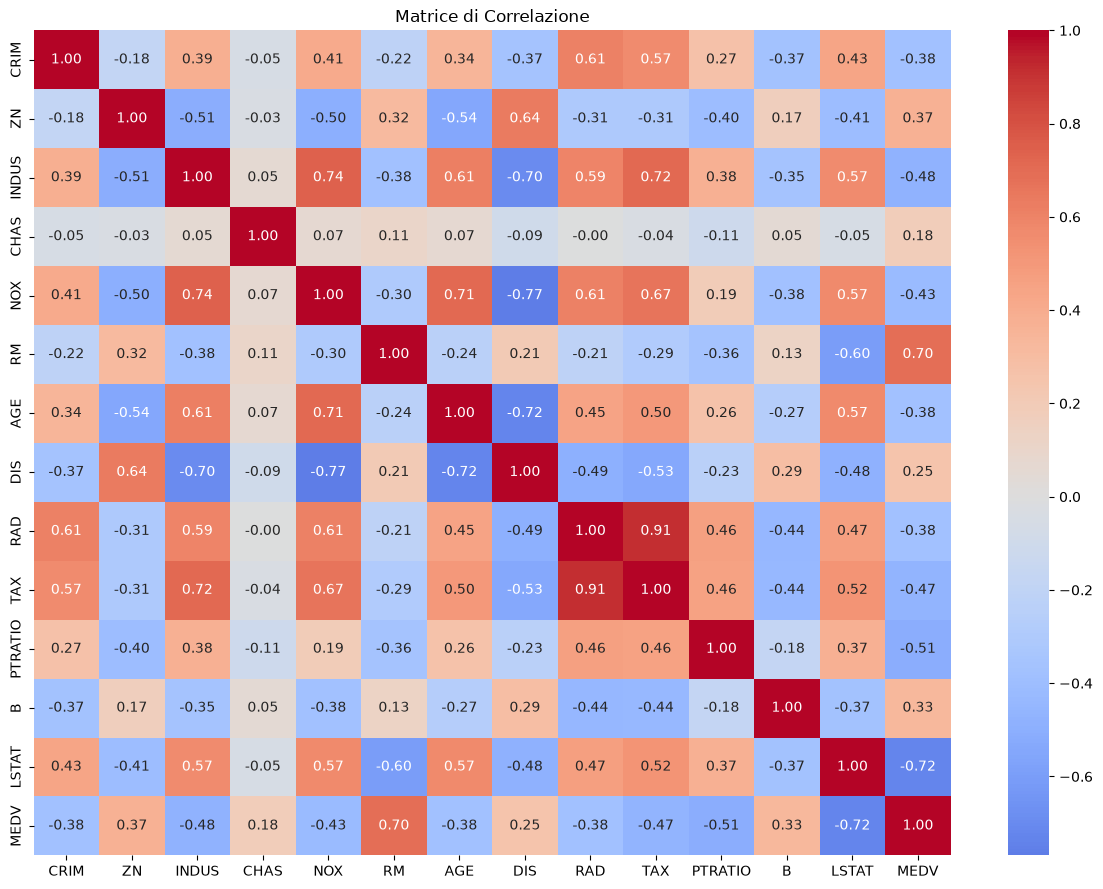


VIF (Multicollinearità):
    Feature         VIF
0     const  579.280864
9       TAX    8.754324
8       RAD    7.284244
4       NOX    4.221522
7       DIS    3.774056
3     INDUS    3.590679
6       AGE    2.738163
12    LSTAT    2.658250
2        ZN    2.176308
5        RM    1.851438
10  PTRATIO    1.798857
1      CRIM    1.717387
11        B    1.349931


In [24]:
## 3. Analisi e Selezione delle Feature

print("=== ANALISI FEATURE ===")

# 3.1 Correlazione con il target (MEDV)
corr_with_target = df_clean.corr()["MEDV"].sort_values(ascending=False)
print("\nCorrelazione con MEDV:")
print(corr_with_target)

# 3.2 Heatmap delle correlazioni
import seaborn as sns
plt.figure(figsize=(12, 9))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice di Correlazione")
plt.tight_layout()
plt.show()

# 3.3 Multicollinearità (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

features_num = ["CRIM", "ZN", "INDUS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]
X_vif = add_constant(df_clean[features_num])

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\nVIF (Multicollinearità):")
print(vif.sort_values("VIF", ascending=False))

In [25]:
## 3.4 Confronto tra diversi set di feature

feature_sets = {
    "1. Tutte le feature": ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"],
    
    "2. Feature Ridotte": ["CRIM", "ZN", "RM", "DIS", "TAX", "PTRATIO", "LSTAT"],
    
    "3. Solo le più forti": ["RM", "LSTAT", "CRIM", "DIS", "PTRATIO"]
}

In [30]:
def evaluate_set(name, features):
    X = df_clean[features]
    y = df_clean["MEDV"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    
    pipeline = make_pipeline(StandardScaler(), LinearRegression())
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5      # versione compatibile
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{name:28} → R² = {r2:.4f} | RMSE = {rmse:.3f} | MAE = {mae:.3f}")
    return r2, rmse, mae

print("\n=== CONFRONTO TRA SET DI FEATURE ===")
for name, feats in feature_sets.items():
    evaluate_set(name, feats)


=== CONFRONTO TRA SET DI FEATURE ===
1. Tutte le feature          → R² = 0.6585 | RMSE = 5.004 | MAE = 3.156
2. Feature Ridotte           → R² = 0.6329 | RMSE = 5.189 | MAE = 3.300
3. Solo le più forti         → R² = 0.6140 | RMSE = 5.320 | MAE = 3.424


## 3. Esplorazione di target e feature

Distribuzione di MEDV, correlazioni e relazione con le feature più rilevanti.

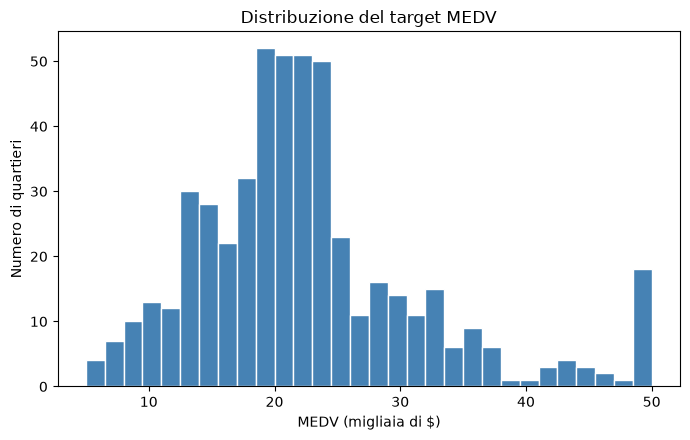

In [8]:
plt.figure()
plt.hist(df_clean["MEDV"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("MEDV (migliaia di $)")
plt.ylabel("Numero di quartieri")
plt.title("Distribuzione del target MEDV")
plt.tight_layout()
plt.show()

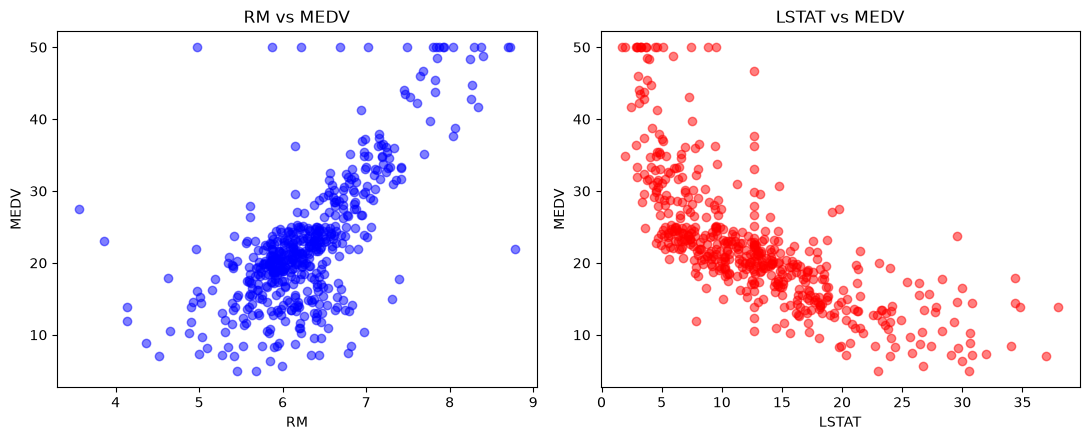

In [10]:
# RM e LSTAT sono le feature piu' correlate con MEDV
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(df_clean["RM"], df_clean["MEDV"], alpha=0.5, color="blue")
axes[0].set_xlabel("RM"); axes[0].set_ylabel("MEDV"); axes[0].set_title("RM vs MEDV")

axes[1].scatter(df_clean["LSTAT"], df_clean["MEDV"], alpha=0.5, color="red")
axes[1].set_xlabel("LSTAT"); axes[1].set_ylabel("MEDV"); axes[1].set_title("LSTAT vs MEDV")

plt.tight_layout()
plt.show()

## 4. Feature e target

In [11]:
X = df_clean.drop(columns=["MEDV"]).values
y = df_clean["MEDV"].values

print("X:", X.shape, "| y:", y.shape)

X: (506, 13) | y: (506,)


## 5. Split train/test (80/20)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 404 | Test: 102


## 6. Standardizzazione

Fit solo sul training set, transform sul test set (nessun data leakage).

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Linear Regression (baseline)

In [14]:
lin_reg = LinearRegression().fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 3.16
RMSE: 5.00
R²  : 0.658


## 8. Ridge Regression

Regolarizzazione L2, alpha fisso a 1.0.

In [15]:
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE : {mae_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²  : {r2_ridge:.3f}")

MAE : 3.15
RMSE: 5.00
R²  : 0.658


## 9. Ridge con Cross-Validation

`GridSearchCV` sceglie alpha con 5-fold CV sul training set, senza toccare il test set.

In [16]:
griglia_alpha = {"alpha": [0.01, 0.1, 1, 10, 30, 100]}

ricerca_ridge = GridSearchCV(Ridge(), griglia_alpha, cv=5, scoring="r2", n_jobs=-1)
ricerca_ridge.fit(X_train_scaled, y_train)

print("Miglior alpha:", ricerca_ridge.best_params_["alpha"])
print("R2 medio in CV:", round(ricerca_ridge.best_score_, 3))

Miglior alpha: 10
R2 medio in CV: 0.714


In [17]:
y_pred_ridge_cv = ricerca_ridge.predict(X_test_scaled)

mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
rmse_ridge_cv = np.sqrt(mean_squared_error(y_test, y_pred_ridge_cv))
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)

print(f"MAE : {mae_ridge_cv:.2f}")
print(f"RMSE: {rmse_ridge_cv:.2f}")
print(f"R²  : {r2_ridge_cv:.3f}")

MAE : 3.15
RMSE: 5.01
R²  : 0.658


## 10. Confronto modelli

In [18]:
risultati = [
    ("Linear Regression", r2, rmse, mae),
    ("Ridge (alpha=1.0)", r2_ridge, rmse_ridge, mae_ridge),
    ("Ridge (CV, alpha ottimo)", r2_ridge_cv, rmse_ridge_cv, mae_ridge_cv),
]

tabella = pd.DataFrame(risultati, columns=["Modello", "R2", "RMSE", "MAE"]).round(3)
tabella

,Modello,R2,RMSE,MAE
0,Linear Regression,0.658,5.004,3.156
1,Ridge (alpha=1.0),0.658,5.005,3.155
2,"Ridge (CV, alpha ottimo)",0.658,5.009,3.146


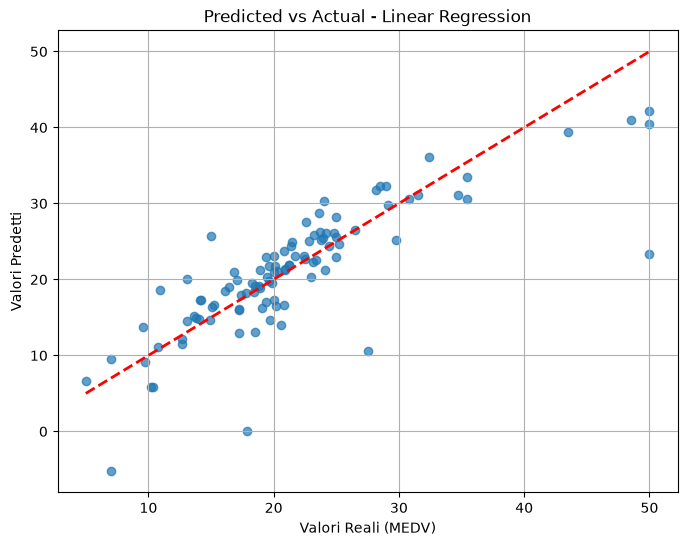

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valori Reali (MEDV)')
plt.ylabel('Valori Predetti')
plt.title('Predicted vs Actual - Linear Regression')
plt.grid(True)
plt.show()

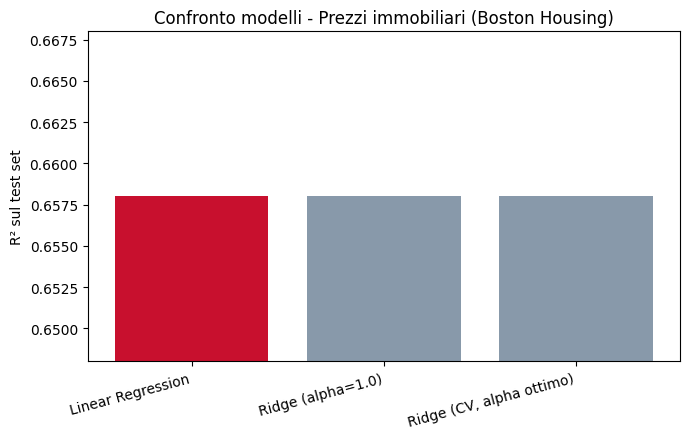

In [18]:
plt.figure()
nomi, valori_r2 = tabella["Modello"], tabella["R2"]

indice_migliore = valori_r2.idxmax()
colori = ["#C8102E" if i == indice_migliore else "#8899aa" for i in range(len(valori_r2))]

plt.bar(nomi, valori_r2, color=colori)
plt.ylabel("R² sul test set")
plt.title("Confronto modelli - Prezzi immobiliari (Boston Housing)")
plt.xticks(rotation=15, ha="right")

margine = (valori_r2.max() - valori_r2.min()) * 0.5 + 0.01
plt.ylim(valori_r2.min() - margine, valori_r2.max() + margine)
plt.tight_layout()
plt.show()

In [31]:
## 4. Modello Finale con Ridge Regression

features_final = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

X = df_clean[features_final]
y = df_clean["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

pipeline = make_pipeline(StandardScaler(), Ridge())

param_grid = {'ridge__alpha': [0.1, 1, 10, 20, 50, 100]}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['ridge__alpha']
y_pred = grid_search.predict(X_test)

print("=== RISULTATI FINALI ===")
print(f"Alpha migliore: {best_alpha}")
print(f"R² sul test set: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")

=== RISULTATI FINALI ===
Alpha migliore: 10
R² sul test set: 0.6579
RMSE: 5.009
MAE: 3.146


## Conclusioni e Analisi delle Feature

L’analisi esplorativa ha giocato un ruolo centrale in questo lavoro. Attraverso la matrice di correlazione e il calcolo del VIF abbiamo potuto valutare l’utilità delle varie feature:

- **Feature più importanti**: `RM` (0.695) e `LSTAT` (-0.738) mostrano la correlazione più forte con il target `MEDV`.
- **Multicollinearità**: `TAX` (VIF ≈ 8.79) e `RAD` (VIF ≈ 7.28) sono fortemente correlate → una delle due è in parte ridondante.
- **Feature con scarso contributo**: `B`, `AGE`, `CHAS` e `INDUS` hanno correlazioni basse e aggiungono rumore.

Abbiamo testato tre diversi subset di feature. Il modello con **tutte le variabili** ha ottenuto le migliori prestazioni (R² = 0.6585 sul test set).

La Ridge Regression con α=10 (selezionato tramite GridSearchCV) ha dato risultati praticamente identici (R² = 0.6579), confermando che il modello lineare base non soffre di overfitting significativo.

**Modello scelto**: **Linear Regression** su tutte le feature.  
Motivazione: offre il miglior compromesso tra performance e semplicità interpretativa. La regolarizzazione non porta benefici sostanziali in questo caso.

Questo progetto sottolinea quanto sia fondamentale, in un problema di regressione, dedicare tempo all’analisi e alla selezione delle feature piuttosto che solo all’addestramento del modello.